# Chapter 0: Introduction to GraphBLAS

Sparse matrices represent graphs efficiently by only storing edges that exist.

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from graph_utils import draw_graph

## A Simple Graph

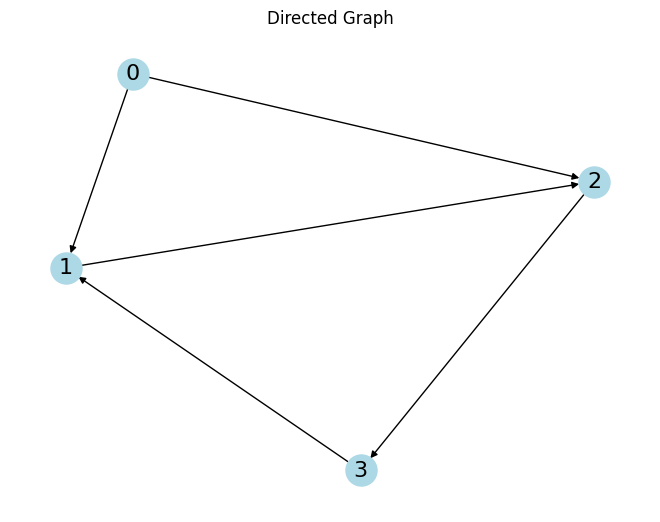

{0: array([-0.25361167,  0.78710236]),
 1: array([-0.36369475, -0.08825725]),
 2: array([0.49947487, 0.30115489]),
 3: array([ 0.11783155, -1.        ])}

In [2]:
# Create a small directed graph
G = nx.DiGraph()
G.add_edges_from([(0, 1), (0, 2), (1, 2), (2, 3), (3, 1)])

draw_graph(G, title="Directed Graph")

## Dense vs Sparse Adjacency Matrix

In [3]:
# Dense representation - stores all n² values
A_dense = nx.to_numpy_array(G, dtype=int)
print("Dense adjacency matrix (stores all 16 values):")
print(A_dense)
print(f"\nStorage: {A_dense.size} values")

Dense adjacency matrix (stores all 16 values):
[[0 1 1 0]
 [0 0 1 0]
 [0 0 0 1]
 [0 1 0 0]]

Storage: 16 values


In [4]:
# Sparse representation - stores only edges
from scipy.sparse import csr_matrix
A_sparse = csr_matrix(A_dense)
print("Sparse adjacency matrix (COO format):")
print(f"Row indices:    {A_sparse.tocoo().row}")
print(f"Column indices: {A_sparse.tocoo().col}")
print(f"Values:         {A_sparse.tocoo().data}")
print(f"\nStorage: {A_sparse.nnz} values (only the edges)")

Sparse adjacency matrix (COO format):
Row indices:    [0 0 1 2 3]
Column indices: [1 2 2 3 1]
Values:         [1 1 1 1 1]

Storage: 5 values (only the edges)


## Matrix-Vector Multiply = One Hop

In [5]:
# Start at node 0
v = np.array([1, 0, 0, 0])
print(f"Starting vector (node 0): {v}")

# One matrix-vector multiply = one hop through the graph
neighbors = A_dense.T @ v
print(f"After one hop (v × A):    {neighbors}")
print(f"\nNodes reachable in 1 hop from node 0: {np.where(neighbors > 0)[0]}")

Starting vector (node 0): [1 0 0 0]
After one hop (v × A):    [0 1 1 0]

Nodes reachable in 1 hop from node 0: [1 2]


In [6]:
# Two hops
two_hops = A_dense.T @ A_dense.T @ v
print(f"After two hops: {two_hops}")
print(f"Nodes reachable in 2 hops: {np.where(two_hops > 0)[0]}")

After two hops: [0 0 1 1]
Nodes reachable in 2 hops: [2 3]
